# California Property Close Price Prediction
## Week 0 to Week 2: setup, data understanding, and exploration

This project studies California home sales and prepares for a model that predicts the final sale price. The target is `ClosePrice`. This notebook uses only February 2025 through April 2026 and only single-family residential properties.

## Week 0 — Understand the task

**Question:** Can property details help us estimate the final sale price of a California single-family home?

**Unit of analysis:** One closed property listing.

**Target:** `ClosePrice`, the amount paid by the buyer.

**Current scope:** Explore the data only. Model preprocessing, training, and testing start in Week 3.

In [1]:
# Import the tools used in this notebook.
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

# Make the path work when Jupyter starts from the project root or notebook folder.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "California"
START_MONTH, END_MONTH = "202502", "202604"
print(f"Project folder: {PROJECT_ROOT}")
print(f"Data period: {START_MONTH} to {END_MONTH}")

Project folder: C:\Users\jackyfirst\Downloads\IDX Exchange DS
Data period: 202502 to 202604


## Week 1 — Confirm access and understand the columns

The files come from CRMLS through the provided FTP server. Raw CSV files are kept unchanged in `data/raw/California`. The field meanings below come from `docs/data_dictionary.pdf`.

| Column | Simple meaning |
|---|---|
| `ClosePrice` | Final amount paid for the property |
| `LivingArea` | Total livable area inside the home |
| `BedroomsTotal` | Total number of bedrooms |
| `BathroomsTotalInteger` | Total bathroom count as a whole number |
| `LotSizeSquareFeet` | Lot area in square feet |
| `CloseDate` | Date when the sale was completed |
| `PropertyType` | Broad property group, such as Residential |
| `PropertySubType` | More specific property group, such as SingleFamilyResidence |
| `YearBuilt` | Year the home was first ready to occupy |
| `City` / `CountyOrParish` | Property location |

In [2]:
# Build the exact list of 15 expected monthly files.
expected_months = pd.period_range(START_MONTH, END_MONTH, freq="M").strftime("%Y%m").tolist()
expected_files = [DATA_DIR / f"CRMLSSold{month}.csv" for month in expected_months]
file_checks = []
for file_path in expected_files:
    record = {"month": file_path.stem[-6:], "file": file_path.name}
    if not file_path.exists():
        record.update(status="missing", rows=np.nan, columns=np.nan)
    else:
        try:
            # Reading each file also catches broken CSV formatting.
            checked = pd.read_csv(file_path, low_memory=False)
            record.update(status="valid", rows=len(checked), columns=len(checked.columns))
        except Exception as error:
            record.update(status=f"invalid: {type(error).__name__}", rows=np.nan, columns=np.nan)
    file_checks.append(record)
file_status = pd.DataFrame(file_checks)
display(file_status)
print(f"Valid months: {(file_status['status'] == 'valid').sum()} of {len(file_status)}")

,month,file,status,rows,columns
0,202502,CRMLSSold202502.csv,valid,"18,702.00",78.00
1,202503,CRMLSSold202503.csv,valid,"21,445.00",78.00
2,202504,CRMLSSold202504.csv,valid,"23,262.00",78.00
3,202505,CRMLSSold202505.csv,valid,"23,154.00",78.00
4,202506,CRMLSSold202506.csv,valid,"22,883.00",78.00
5,202507,CRMLSSold202507.csv,invalid: ParserError,NaN,NaN
6,202508,CRMLSSold202508.csv,valid,"22,972.00",78.00
7,202509,CRMLSSold202509.csv,valid,"22,443.00",78.00
8,202510,CRMLSSold202510.csv,valid,"23,233.00",78.00
9,202511,CRMLSSold202511.csv,valid,"19,088.00",78.00


Valid months: 14 of 15


The July 2025 source file is incomplete and ends inside a quoted value. We leave the raw file unchanged and skip it. The remaining 14 valid months still exceed the six-month minimum.

In [3]:
# Load only the fields needed for this exploration.
columns = ["ListingKey", "CloseDate", "ClosePrice", "PropertyType",
           "PropertySubType", "LivingArea", "BedroomsTotal",
           "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt",
           "City", "CountyOrParish"]
frames = []
valid_files = [row.file for row in file_status.itertuples() if row.status == "valid"]
for file_name in valid_files:
    monthly = pd.read_csv(DATA_DIR / file_name, usecols=columns, low_memory=False)
    monthly["SourceMonth"] = file_name[-10:-4]
    frames.append(monthly)
raw_df = pd.concat(frames, ignore_index=True)
print(f"Loaded rows: {len(raw_df):,}")
print(f"Loaded valid months: {raw_df['SourceMonth'].nunique()}")
display(raw_df.head())

Loaded rows: 298,326
Loaded valid months: 14


,ListingKey,CloseDate,ClosePrice,PropertyType,LivingArea,CountyOrParish,PropertySubType,YearBuilt,BathroomsTotalInteger,City,BedroomsTotal,LotSizeSquareFeet,SourceMonth
0,526199946,2025-02-21,"35,000.00",Land,NaN,San Bernardino,NaN,NaN,NaN,Apple Valley,NaN,"28,000.00",202502
1,525585060,2025-02-14,"625,000.00",Land,NaN,Riverside,NaN,NaN,NaN,Moreno Valley,NaN,"39,640.00",202502
2,497696903,2025-02-11,"875,000.00",Residential,"2,340.00",San Diego,SingleFamilyResidence,"2,021.00",4.00,La Mesa,4.00,NaN,202502
3,497696407,2025-02-14,"875,000.00",Residential,"2,165.00",San Diego,SingleFamilyResidence,"2,021.00",4.00,La Mesa,5.00,NaN,202502
4,486616176,2025-02-18,"849,000.00",Residential,"2,158.00",San Diego,SingleFamilyResidence,"2,021.00",3.00,La Mesa,4.00,NaN,202502


## Week 2 — Filter and clean for exploration

The task asks us to use only `Residential` and `SingleFamilyResidence`. Numeric text is converted to numbers. Rows with a missing or non-positive target are not useful for price analysis, so they are removed from the EDA copy only. Raw files remain untouched.

In [4]:
# Apply the property segment required by the task.
segment_mask = (raw_df["PropertyType"].astype("string").str.strip().eq("Residential")
                & raw_df["PropertySubType"].astype("string").str.strip().eq("SingleFamilyResidence"))
df = raw_df.loc[segment_mask].copy()
numeric_columns = ["ClosePrice", "LivingArea", "BedroomsTotal",
                   "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
rows_before_target_check = len(df)
df = df[df["ClosePrice"] > 0].copy()
print(f"Rows after property filter: {rows_before_target_check:,}")
print(f"Rows with a positive close price: {len(df):,}")
print(f"Unique listings: {df['ListingKey'].nunique():,}")
print(f"Duplicate listing keys: {df['ListingKey'].duplicated().sum():,}")
print(f"Close dates: {df['CloseDate'].min().date()} to {df['CloseDate'].max().date()}")

Rows after property filter: 149,200
Rows with a positive close price: 149,200
Unique listings: 149,094
Duplicate listing keys: 106
Close dates: 2025-02-01 to 2026-04-30


### Missing values and summary

Missing values show which fields need a decision in Week 3. At this stage, we measure them instead of filling them.

In [5]:
# Measure completeness for the target and main features.
eda_columns = ["ClosePrice", "LivingArea", "BedroomsTotal",
               "BathroomsTotalInteger", "LotSizeSquareFeet"]
missing_summary = pd.DataFrame({
    "missing_rows": df[eda_columns].isna().sum(),
    "missing_percent": df[eda_columns].isna().mean().mul(100),
}).sort_values("missing_percent", ascending=False)
display(missing_summary)
display(df[eda_columns].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T)

,missing_rows,missing_percent
LotSizeSquareFeet,2607,1.75
LivingArea,82,0.05
BathroomsTotalInteger,16,0.01
ClosePrice,0,0.00
BedroomsTotal,0,0.00


,count,mean,std,min,1%,25%,50%,75%,99%,max
ClosePrice,"149,200.00","1,342,089.03","8,120,129.00",1.75,"235,000.00","625,000.00","890,000.00","1,424,000.00","6,425,040.00","989,500,000.00"
LivingArea,"149,118.00","2,044.99","1,029.25",0.00,740.00,"1,385.00","1,816.00","2,438.00","5,649.83","31,068.00"
BedroomsTotal,"149,200.00",3.49,0.97,0.00,2.00,3.00,3.00,4.00,6.00,45.00
BathroomsTotalInteger,"149,184.00",2.63,1.13,0.00,1.00,2.00,2.00,3.00,6.00,45.00
LotSizeSquareFeet,"146,593.00","378,454.99","18,399,709.65",0.00,"1,747.00","5,663.00","7,277.00","10,454.00","267,963.70","2,087,220,960.00"


### Target and feature distributions

Real estate data has a small number of very large values. The plots use the 1st to 99th percentile range so the common pattern is easy to see. No values are deleted from the dataframe.

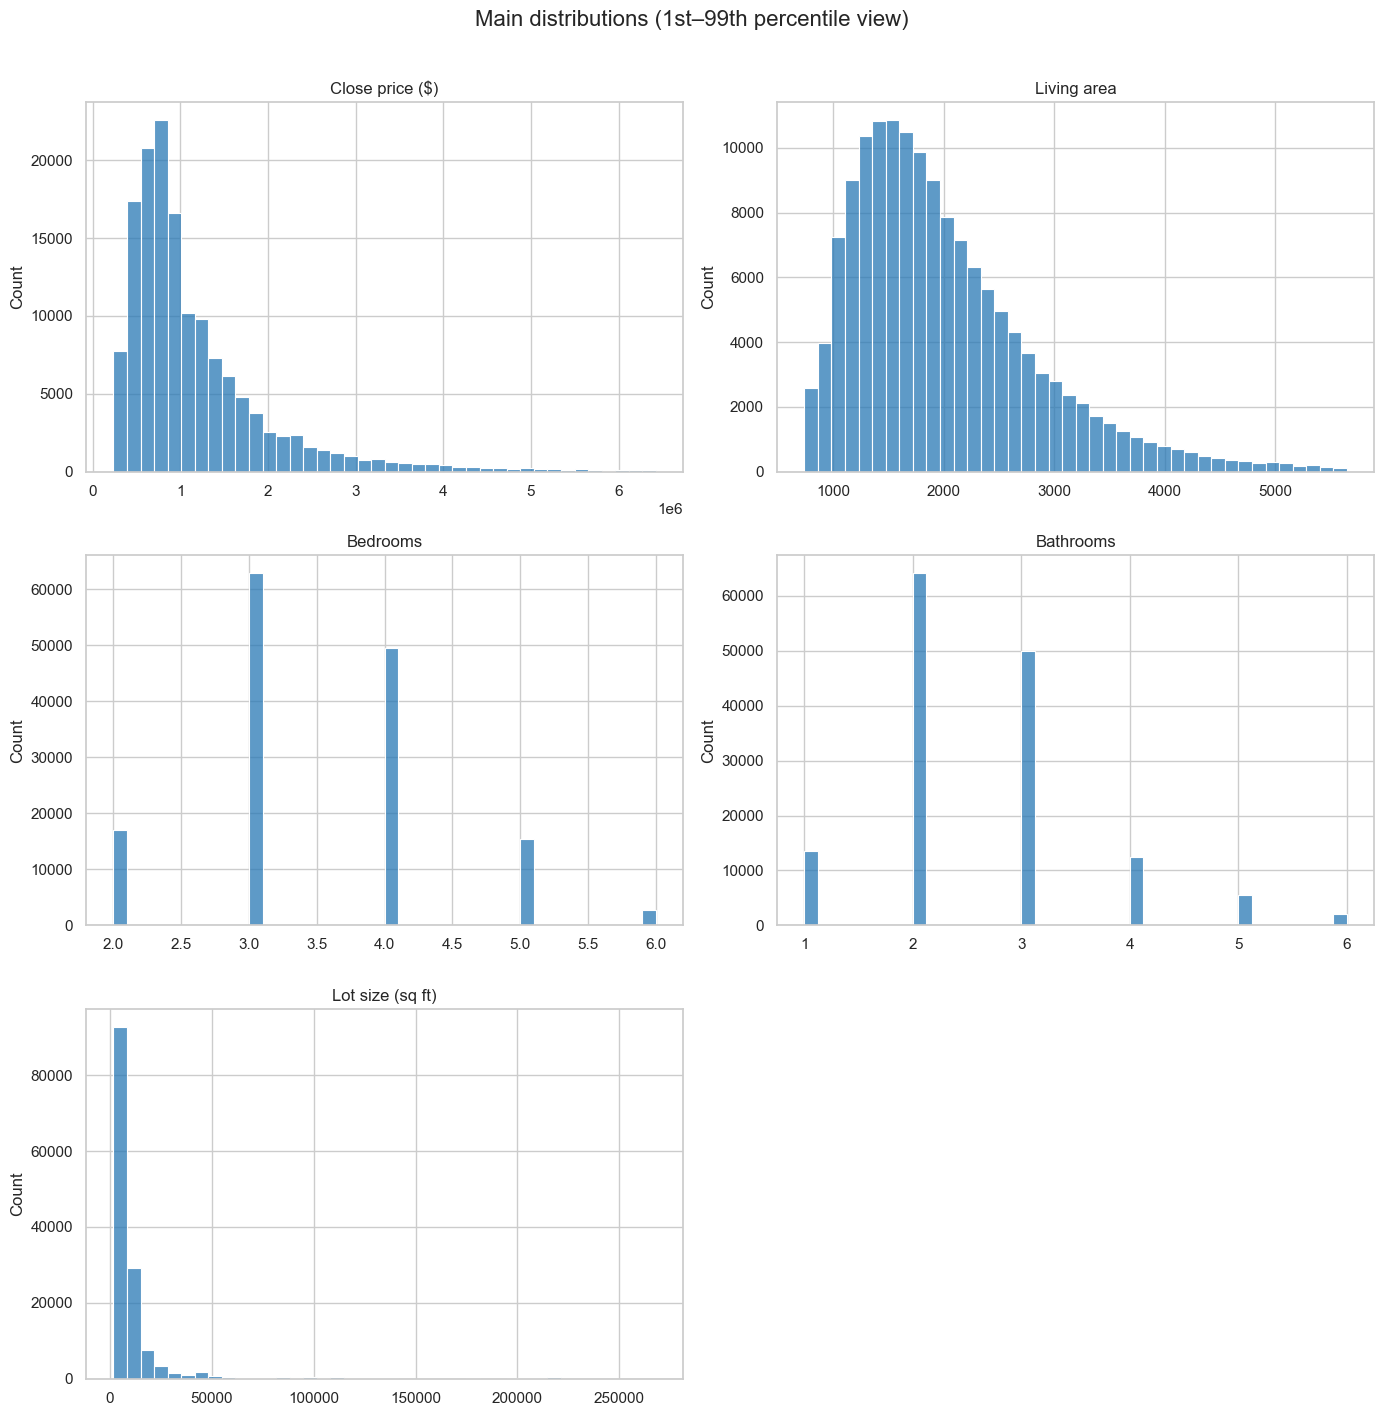

In [6]:
# Plot the common range while keeping all original values in df.
plot_titles = {"ClosePrice": "Close price ($)", "LivingArea": "Living area",
               "BedroomsTotal": "Bedrooms", "BathroomsTotalInteger": "Bathrooms",
               "LotSizeSquareFeet": "Lot size (sq ft)"}
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for axis, column in zip(axes.flat, eda_columns):
    values = df[column].dropna()
    lower, upper = values.quantile([0.01, 0.99])
    sns.histplot(values[values.between(lower, upper)], bins=40, ax=axis, color="#2878B5")
    axis.set_title(plot_titles[column])
    axis.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Main distributions (1st–99th percentile view)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Relationships with close price

Correlation gives a quick view of monotonic relationships. The scatter plots use a reproducible sample so the notebook stays readable and fast.

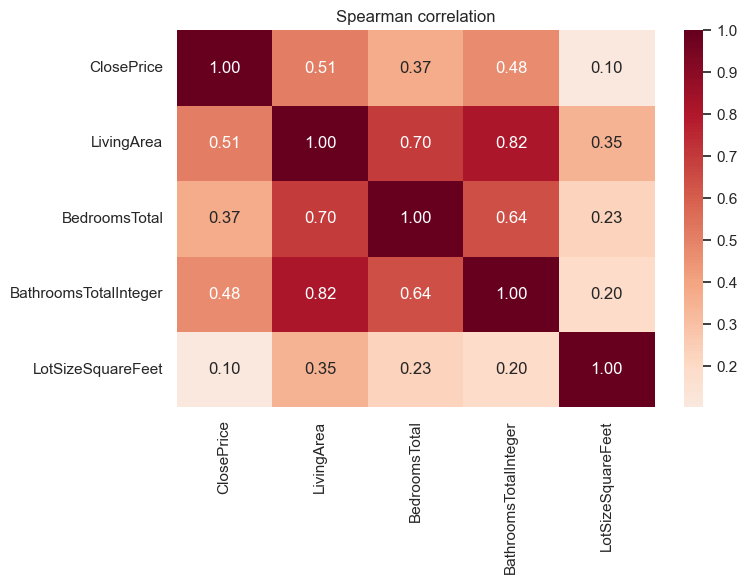

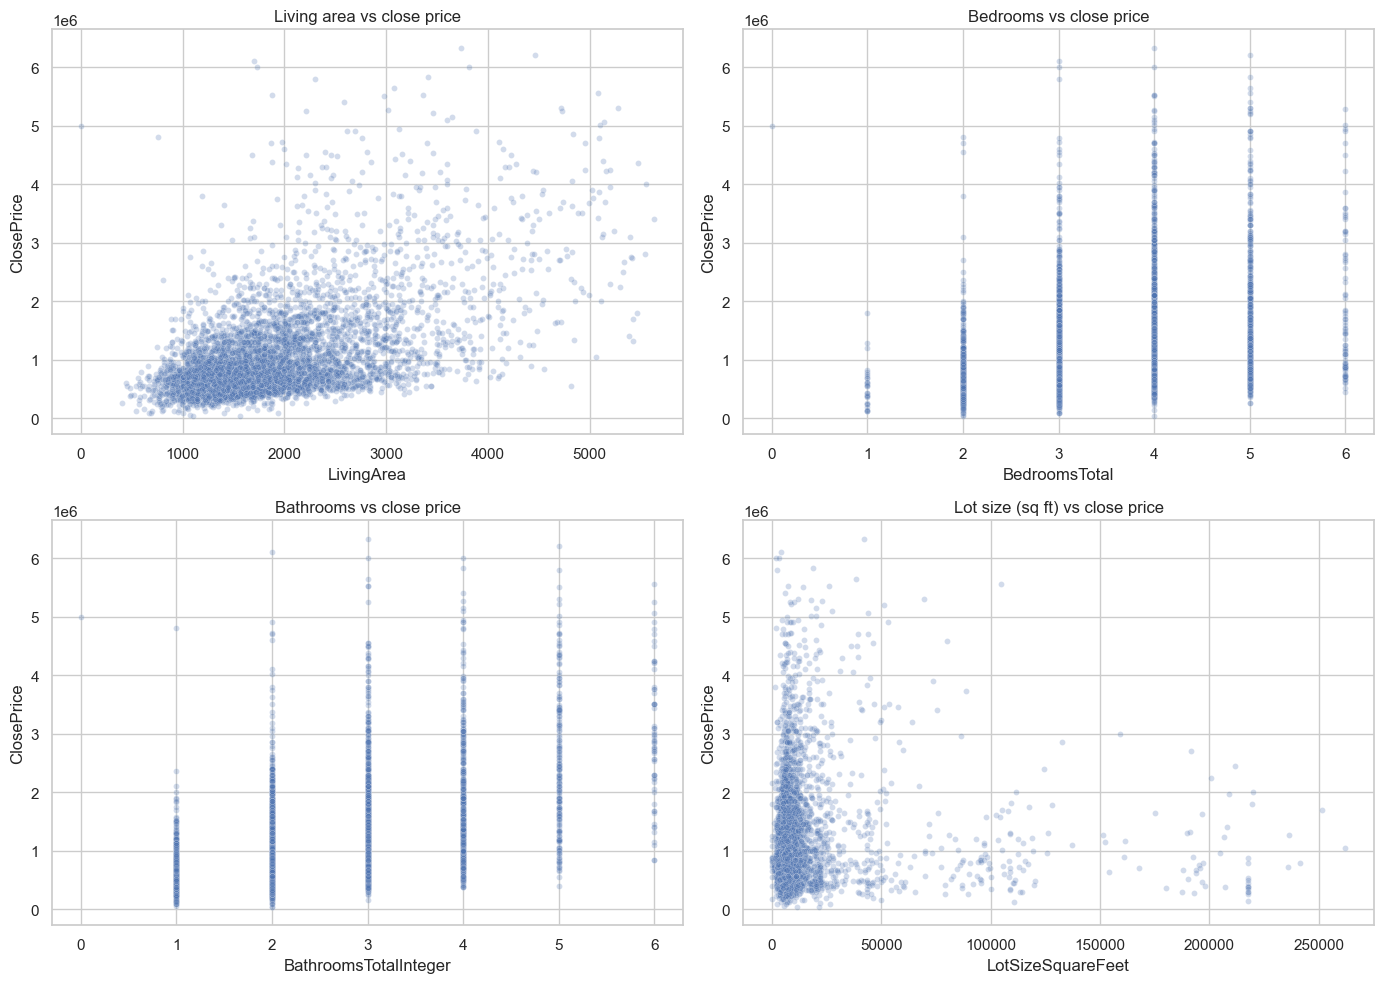

In [7]:
# Compare numeric features with the target.
correlation = df[eda_columns].corr(method="spearman")
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Spearman correlation")
plt.tight_layout()
plt.show()

# Limit extreme values only for a clearer picture.
scatter_columns = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
sample = df.sample(n=min(5000, len(df)), random_state=42)
price_cap = df["ClosePrice"].quantile(0.99)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, column in zip(axes.flat, scatter_columns):
    x_cap = df[column].quantile(0.99)
    view = sample[(sample["ClosePrice"] <= price_cap) & (sample[column] <= x_cap)]
    sns.scatterplot(data=view, x=column, y="ClosePrice", alpha=0.25, s=18, ax=axis)
    axis.set_title(f"{plot_titles[column]} vs close price")
plt.tight_layout()
plt.show()

### Monthly pattern and simple findings

,SourceMonth,sales,median_close_price,median_living_area
0,202502,8851,"900,000.00","1,800.00"
1,202503,10610,"887,000.00","1,816.00"
2,202504,11880,"900,000.00","1,806.00"
3,202505,11777,"905,000.00","1,815.00"
4,202506,11701,"910,000.00","1,836.00"
5,202508,11454,"885,500.00","1,806.00"
6,202509,11456,"880,000.00","1,806.00"
7,202510,12029,"888,163.00","1,824.00"
8,202511,9739,"875,000.00","1,812.00"
9,202512,10455,"860,000.00","1,804.00"


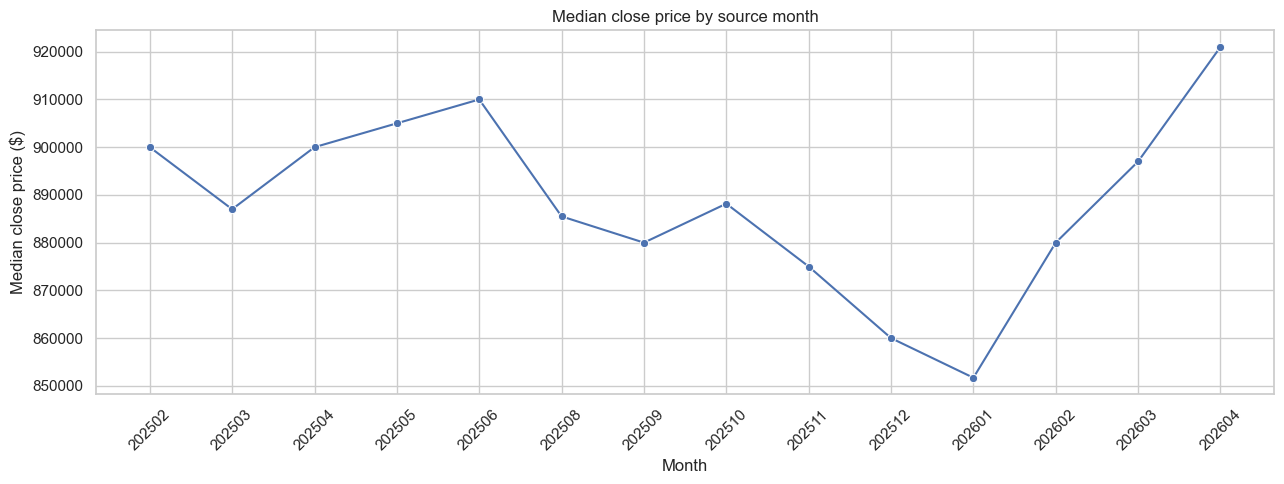

Median close price: $890,000
Strongest simple relationship: LivingArea (Spearman 0.51)
Feature needing the most missing-value work: LotSizeSquareFeet (1.7%)


In [8]:
# Use medians because a few luxury sales can strongly move the mean.
monthly_summary = (df.groupby("SourceMonth")
    .agg(sales=("ClosePrice", "size"), median_close_price=("ClosePrice", "median"),
         median_living_area=("LivingArea", "median"))
    .reset_index())
display(monthly_summary)
fig, ax1 = plt.subplots(figsize=(13, 5))
sns.lineplot(data=monthly_summary, x="SourceMonth", y="median_close_price", marker="o", ax=ax1)
ax1.set_title("Median close price by source month")
ax1.set_xlabel("Month")
ax1.set_ylabel("Median close price ($)")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
target_median = df['ClosePrice'].median()
strongest_feature = correlation['ClosePrice'].drop('ClosePrice').abs().idxmax()
strongest_value = correlation.loc[strongest_feature, 'ClosePrice']
most_missing = missing_summary.index[0]
print(f"Median close price: ${target_median:,.0f}")
print(f"Strongest simple relationship: {strongest_feature} (Spearman {strongest_value:.2f})")
print(f"Feature needing the most missing-value work: {most_missing} ({missing_summary.loc[most_missing, 'missing_percent']:.1f}%)")

## Week 0–2 conclusion

- Dataset access and the requested date range are confirmed.
- One official source file, July 2025, is broken and is clearly excluded.
- The analysis is restricted to residential single-family homes.
- Close price and the four required features have been checked for shape, missing values, outliers, and basic relationships.
- The price distribution is right-skewed, so medians and robust views are more useful than averages alone.
- Week 3 should decide how to handle missing values, duplicates, and unusual values before creating a time-based train/test split.